In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
sales = pd.read_csv('sales.csv')
products = pd.read_csv('product_hierarchy.csv')
stores = pd.read_csv('store_cities.csv')

# Basic information
print("Sales Dataset Shape:", sales.shape)
print("Products Dataset Shape:", products.shape)
print("Stores Dataset Shape:", stores.shape)

print("\nSales Columns:")
print(sales.columns)

print("\nMissing Values:")
print(sales.isnull().sum())

sales.head()

Sales Dataset Shape: (323983, 13)
Products Dataset Shape: (699, 10)
Stores Dataset Shape: (144, 4)

Sales Columns:
Index(['product_id', 'store_id', 'date', 'sales', 'revenue', 'stock', 'price',
       'promo_type_1', 'promo_bin_1', 'promo_type_2', 'promo_bin_2',
       'promo_discount_2', 'promo_discount_type_2'],
      dtype='object')

Missing Values:
product_id                    0
store_id                      1
date                          1
sales                         1
revenue                       1
stock                         1
price                      4768
promo_type_1                  1
promo_bin_1              291039
promo_type_2                  1
promo_bin_2              323983
promo_discount_2         323983
promo_discount_type_2    323983
dtype: int64


,product_id,store_id,date,sales,revenue,stock,price,promo_type_1,promo_bin_1,promo_type_2,promo_bin_2,promo_discount_2,promo_discount_type_2
0,P0001,S0002,2017-01-02,0.0,0.00,8.0,6.25,PR14,NaN,PR03,NaN,NaN,NaN
1,P0001,S0012,2017-01-02,1.0,5.30,0.0,6.25,PR14,NaN,PR03,NaN,NaN,NaN
2,P0001,S0013,2017-01-02,2.0,10.59,0.0,6.25,PR14,NaN,PR03,NaN,NaN,NaN
3,P0001,S0023,2017-01-02,0.0,0.00,6.0,6.25,PR14,NaN,PR03,NaN,NaN,NaN
4,P0001,S0025,2017-01-02,0.0,0.00,1.0,6.25,PR14,NaN,PR03,NaN,NaN,NaN


In [2]:
# Data Cleaning

# Convert date column to datetime
sales['date'] = pd.to_datetime(sales['date'])

# Check duplicates
print("Duplicate Rows:", sales.duplicated().sum())

# Fill missing prices with median price
sales['price'] = sales['price'].fillna(sales['price'].median())

# Check remaining missing values
print("\nRemaining Missing Values:")
print(sales.isnull().sum())

# Basic statistics
print("\nSummary Statistics:")
print(sales[['sales', 'revenue', 'stock', 'price']].describe())

Duplicate Rows: 0

Remaining Missing Values:
product_id                    0
store_id                      1
date                          1
sales                         1
revenue                       1
stock                         1
price                         0
promo_type_1                  1
promo_bin_1              291039
promo_type_2                  1
promo_bin_2              323983
promo_discount_2         323983
promo_discount_type_2    323983
dtype: int64

Summary Statistics:
               sales        revenue          stock          price
count  323982.000000  323982.000000  323982.000000  323983.000000
mean        0.575716       2.302651      16.233107       8.983096
std         3.880363      66.189460      40.337176      10.874820
min         0.000000       0.000000       0.000000       0.250000
25%         0.000000       0.000000       4.000000       2.500000
50%         0.000000       0.000000       8.000000       5.750000
75%         0.000000       0.000000      17

Total Sales: 186521.7
Total Revenue: 746017.44

Top 10 Products by Revenue
product_id
P0129    249060.36
P0103     34663.54
P0351     27929.26
P0500     21048.76
P0413     16104.29
P0261     11484.84
P0569      9939.40
P0718      8438.31
P0325      8331.12
P0316      8137.46
Name: revenue, dtype: float64


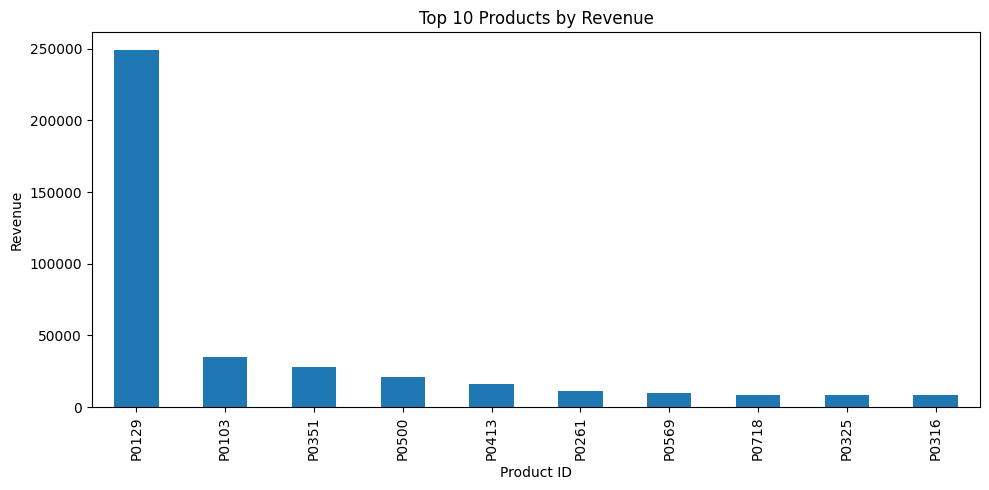

In [3]:
# Business Metrics

total_sales = sales['sales'].sum()
total_revenue = sales['revenue'].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Revenue:", round(total_revenue, 2))

# Top 10 Products by Revenue
top_products = sales.groupby('product_id')['revenue'].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Products by Revenue")
print(top_products)

# Visualization
plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.ylabel('Revenue')
plt.xlabel('Product ID')
plt.tight_layout()
plt.show()

Top 10 Stores by Revenue
store_id
S0097    48734.42
S0085    44288.95
S0062    43385.95
S0026    35713.95
S0020    29155.55
S0095    26918.36
S0038    18051.36
S0104    16899.39
S0040    13459.82
S0051    13407.30
Name: revenue, dtype: float64


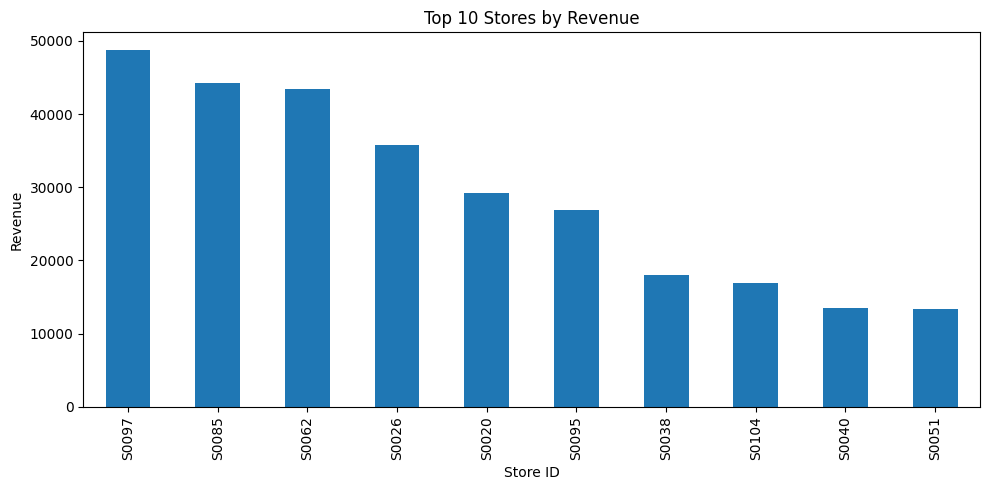

In [4]:
# Top 10 Stores by Revenue

top_stores = sales.groupby('store_id')['revenue'].sum().sort_values(ascending=False).head(10)

print("Top 10 Stores by Revenue")
print(top_stores)

plt.figure(figsize=(10,5))
top_stores.plot(kind='bar')
plt.title('Top 10 Stores by Revenue')
plt.ylabel('Revenue')
plt.xlabel('Store ID')
plt.tight_layout()
plt.show()

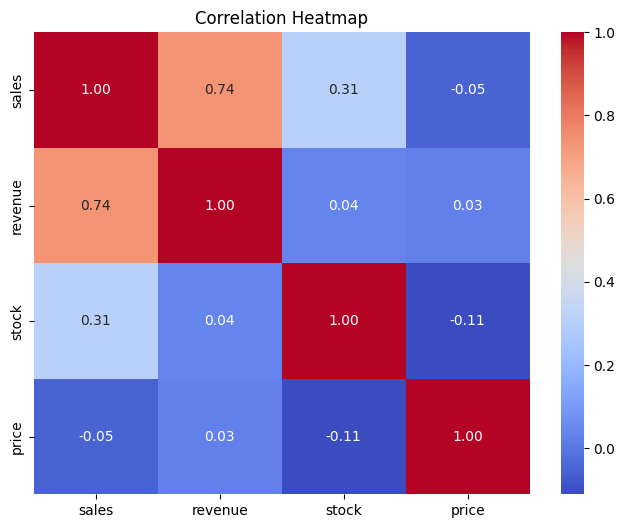

In [5]:
# Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = sales[['sales', 'revenue', 'stock', 'price']]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


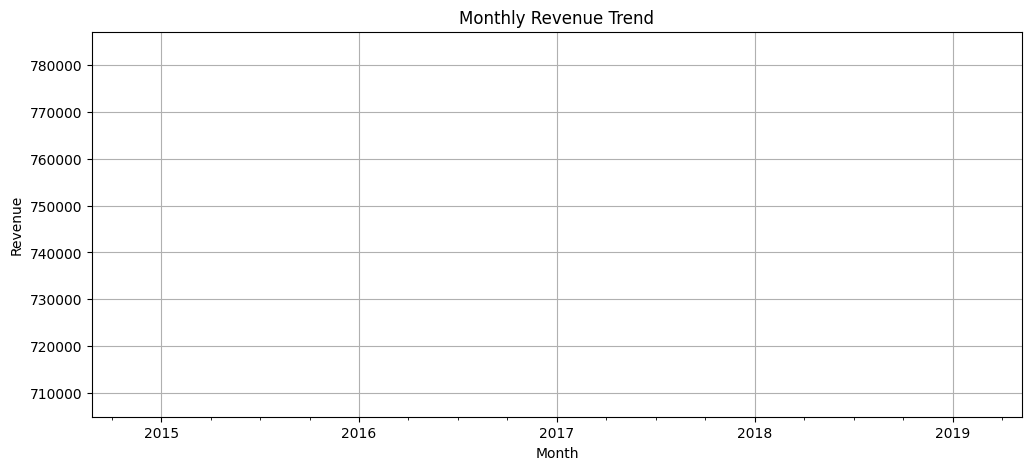

In [6]:
# Monthly Revenue Trend

sales['Month'] = sales['date'].dt.to_period('M')

monthly_revenue = sales.groupby('Month')['revenue'].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)

plt.show()

In [7]:
print("Earliest Date:", sales['date'].min())
print("Latest Date:", sales['date'].max())

print("\nUnique Months:")
print(sales['date'].dt.to_period('M').unique())

Earliest Date: 2017-01-02 00:00:00
Latest Date: 2017-01-26 00:00:00

Unique Months:
<PeriodArray>
['2017-01', 'NaT']
Length: 2, dtype: period[M]


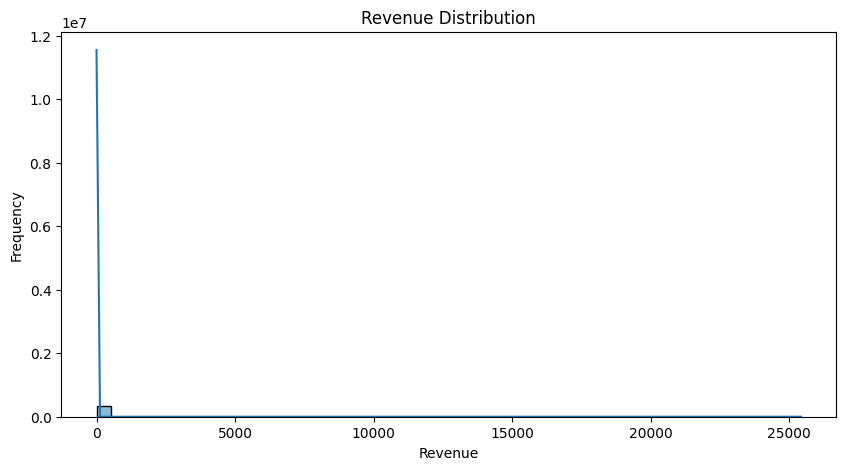

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(sales['revenue'], bins=50, kde=True)

plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.show()

In [9]:
print(products.head())
print("\n")
print(products.columns)

  product_id  product_length  product_depth  product_width cluster_id  \
0      P0000             5.0           20.0           12.0        NaN   
1      P0001            13.5           22.0           20.0  cluster_5   
2      P0002            22.0           40.0           22.0  cluster_0   
3      P0004             2.0           13.0            4.0  cluster_3   
4      P0005            16.0           30.0           16.0  cluster_9   

  hierarchy1_id hierarchy2_id hierarchy3_id hierarchy4_id hierarchy5_id  
0           H00         H0004       H000401     H00040105   H0004010534  
1           H01         H0105       H010501     H01050100   H0105010006  
2           H03         H0315       H031508     H03150800   H0315080028  
3           H03         H0314       H031405     H03140500   H0314050003  
4           H03         H0312       H031211     H03121109   H0312110917  


Index(['product_id', 'product_length', 'product_depth', 'product_width',
       'cluster_id', 'hierarchy1_id', 'hie

In [11]:
# Merge sales and product data

sales_products = sales.merge(
    products,
    on='product_id',
    how='left'
)

print("Merged Dataset Shape:", sales_products.shape)

sales_products.head()

Merged Dataset Shape: (323983, 23)


,product_id,store_id,date,sales,revenue,stock,price,promo_type_1,promo_bin_1,promo_type_2,...,Month,product_length,product_depth,product_width,cluster_id,hierarchy1_id,hierarchy2_id,hierarchy3_id,hierarchy4_id,hierarchy5_id
0,P0001,S0002,2017-01-02,0.0,0.00,8.0,6.25,PR14,NaN,PR03,...,2017-01,13.5,22.0,20.0,cluster_5,H01,H0105,H010501,H01050100,H0105010006
1,P0001,S0012,2017-01-02,1.0,5.30,0.0,6.25,PR14,NaN,PR03,...,2017-01,13.5,22.0,20.0,cluster_5,H01,H0105,H010501,H01050100,H0105010006
2,P0001,S0013,2017-01-02,2.0,10.59,0.0,6.25,PR14,NaN,PR03,...,2017-01,13.5,22.0,20.0,cluster_5,H01,H0105,H010501,H01050100,H0105010006
3,P0001,S0023,2017-01-02,0.0,0.00,6.0,6.25,PR14,NaN,PR03,...,2017-01,13.5,22.0,20.0,cluster_5,H01,H0105,H010501,H01050100,H0105010006
4,P0001,S0025,2017-01-02,0.0,0.00,1.0,6.25,PR14,NaN,PR03,...,2017-01,13.5,22.0,20.0,cluster_5,H01,H0105,H010501,H01050100,H0105010006


cluster_id
cluster_0    537462.71
cluster_9     42219.65
cluster_2     34904.68
cluster_7     34787.07
cluster_4     23045.17
cluster_6     18363.37
cluster_3     17695.37
cluster_8     15290.14
cluster_5     13656.38
cluster_1      8592.90
Name: revenue, dtype: float64


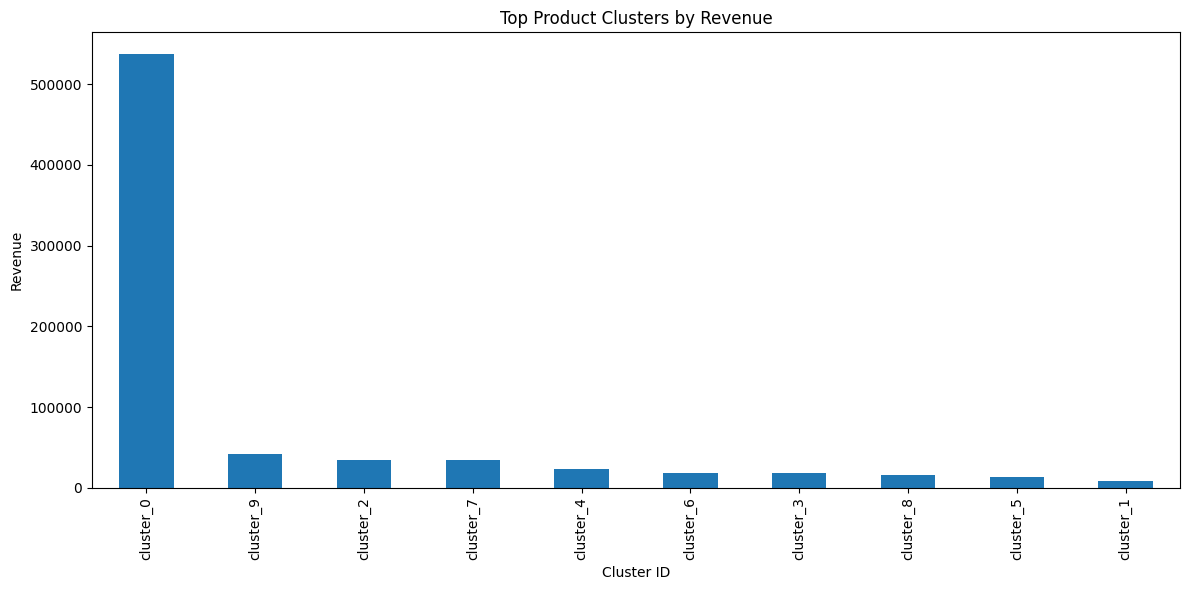

In [12]:
# Revenue by Product Cluster

cluster_revenue = (
    sales_products
    .groupby('cluster_id')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(cluster_revenue)

plt.figure(figsize=(12,6))
cluster_revenue.plot(kind='bar')

plt.title('Top Product Clusters by Revenue')
plt.xlabel('Cluster ID')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

In [13]:
print(stores.head())
print("\n")
print(stores.columns)

  store_id storetype_id  store_size city_id
0    S0091         ST04          19    C013
1    S0012         ST04          28    C005
2    S0045         ST04          17    C008
3    S0032         ST03          14    C019
4    S0027         ST04          24    C022


Index(['store_id', 'storetype_id', 'store_size', 'city_id'], dtype='object')


In [14]:
# Merge store information

final_df = sales_products.merge(
    stores,
    on='store_id',
    how='left'
)

print("Final Dataset Shape:", final_df.shape)

final_df.head()

Final Dataset Shape: (323983, 26)


,product_id,store_id,date,sales,revenue,stock,price,promo_type_1,promo_bin_1,promo_type_2,...,product_width,cluster_id,hierarchy1_id,hierarchy2_id,hierarchy3_id,hierarchy4_id,hierarchy5_id,storetype_id,store_size,city_id
0,P0001,S0002,2017-01-02,0.0,0.00,8.0,6.25,PR14,NaN,PR03,...,20.0,cluster_5,H01,H0105,H010501,H01050100,H0105010006,ST04,39.0,C007
1,P0001,S0012,2017-01-02,1.0,5.30,0.0,6.25,PR14,NaN,PR03,...,20.0,cluster_5,H01,H0105,H010501,H01050100,H0105010006,ST04,28.0,C005
2,P0001,S0013,2017-01-02,2.0,10.59,0.0,6.25,PR14,NaN,PR03,...,20.0,cluster_5,H01,H0105,H010501,H01050100,H0105010006,ST04,33.0,C026
3,P0001,S0023,2017-01-02,0.0,0.00,6.0,6.25,PR14,NaN,PR03,...,20.0,cluster_5,H01,H0105,H010501,H01050100,H0105010006,ST04,31.0,C008
4,P0001,S0025,2017-01-02,0.0,0.00,1.0,6.25,PR14,NaN,PR03,...,20.0,cluster_5,H01,H0105,H010501,H01050100,H0105010006,ST04,25.0,C024


city_id
C014    327502.41
C022     71684.81
C031     43597.88
C036     37784.20
C025     22142.46
C024     18728.97
C004     18051.36
C002     16899.39
C029     16406.11
C008     15486.55
Name: revenue, dtype: float64


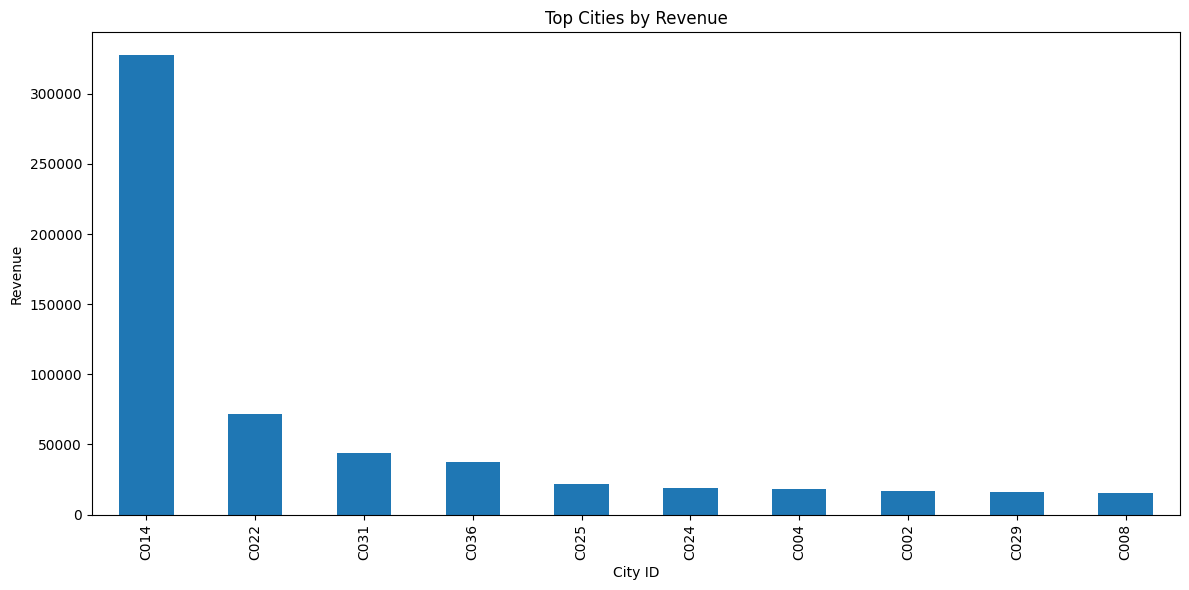

In [15]:
# Top Cities by Revenue

city_revenue = (
    final_df
    .groupby('city_id')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(city_revenue)

plt.figure(figsize=(12,6))
city_revenue.plot(kind='bar')

plt.title('Top Cities by Revenue')
plt.xlabel('City ID')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()